# D6 — SDMX Cross-Country Analysis

## Objective

In the previous notebook, we transformed BIS SDMX data into an analysis-ready dataset and explored the time-series behaviour of a single economy. While country-level analysis is valuable, most macroeconomic research involves comparing multiple economies to identify differences, similarities, and long-term trends.

The objective of this notebook is to build a cross-country analytical workflow using official BIS SDMX data.

Using the BIS Total Credit dataset, we will:

- Retrieve data for multiple economies using a single SDMX query.
- Build a tidy panel dataset suitable for cross-country analysis.
- Compare credit indicators across economies and over time.
- Rank countries based on macroeconomic indicators.
- Analyse cross-country growth dynamics and historical trends.
- Visualise similarities and differences using comparative charts and summary tables.
- Generate concise country-level analytical profiles.

By the end of this notebook, we will have extended our SDMX workflow from analysing a single country to performing comparative macroeconomic analysis across multiple economies, following the type of exploratory work commonly carried out by economists and quantitative analysts.

---

## Learning Outcomes

After completing this notebook, you will be able to:

- Retrieve and combine multiple SDMX time series into a unified panel dataset.
- Perform cross-country comparisons using official BIS macroeconomic indicators.
- Construct reusable analytical workflows for panel data.
- Rank and benchmark countries using economic indicators.
- Produce publication-ready comparative visualisations.
- Prepare multi-country datasets for subsequent statistical modelling and forecasting.

This notebook marks the transition from **single-country time-series analysis** to **cross-country macroeconomic analysis**, an essential skill in applied economic research.

```text
Retrieve BIS SDMX Data
        │
        ▼
Multiple Country Time Series
        │
        ▼
Analysis-Ready Panel Dataset
        │
        ▼
Cross-Country Comparative Analysis
        │
        ▼
Country Ranking & Benchmarking
        │
        ▼
Comparative Visualizations
        │
        ▼
Derived Economic Insights
```

In [2]:
# ----------------------------------------------------
# Import Libraries
# ----------------------------------------------------

import sdmx
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ----------------------------------------------------
# Connect to BIS
# ----------------------------------------------------

client = sdmx.Client("BIS")

print(client.source.id)
print(client.source.url)

BIS
https://stats.bis.org/api/v1


In [7]:
# ----------------------------------------------------
# Select Dataflow
# ----------------------------------------------------

DATAFLOW_ID = "WS_TC"

print(DATAFLOW_ID)

WS_TC


In [8]:
# ----------------------------------------------------
# Retrieve Dataflow
# ----------------------------------------------------

flow_response = client.dataflow()

flow = flow_response.dataflow[DATAFLOW_ID]

print(flow.id)
print(flow.name)

WS_TC
Total credit


In [11]:
# ----------------------------------------------------
# Retrieve Data Structure Definition (DSD)
# ----------------------------------------------------

dsd_response = client.datastructure(flow.structure.id)

print(type(dsd_response))
print(dsd_response.structure.keys())

<class 'sdmx.message.StructureMessage'>
dict_keys(['BIS_TOTAL_CREDIT'])


In [12]:
# ----------------------------------------------------
# Get the Data Structure Definition
# ----------------------------------------------------

dsd = dsd_response.structure["BIS_TOTAL_CREDIT"]

print(dsd.id)
print(dsd.name)

BIS_TOTAL_CREDIT
BIS long series on total credit


In [14]:
# ----------------------------------------------------
# Inspect a Dimension Object
# ----------------------------------------------------

first_dim = dsd.dimensions.components[0]

print(type(first_dim))

print("\nAvailable Attributes:")
print(dir(first_dim))

<class 'sdmx.model.common.Dimension'>

Available Attributes:
['__annotations__', '__class__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__replace__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_preserve', '_urn', 'annotations', 'compare', 'concept_identity', 'concept_role', 'eval_annotation', 'get_annotation', 'id', 'local_representation', 'order', 'pop_annotation', 'uri', 'urn']


In [15]:
print(first_dim)

FREQ


In [16]:
vars(first_dim)

{'concept_identity': <Concept FREQ: Frequency>,
 'local_representation': <Representation: CL_FREQ, [Facet(type=FacetType(is_sequence='false', min_length=1, max_length=1, min_value=None, max_value=None, start_value=None, end_value=None, interval=None, time_interval=None, decimals=None, pattern=None, start_time=None, end_time=None, sentinel_values=None), value=None, value_type=<FacetValueType.string: 1>)]>,
 'order': 1,
 'concept_role': None,
 '_urn': URN(package='datastructure', klass='Dimension', agency='BIS', id='BIS_TOTAL_CREDIT', version='2.0', item_id='FREQ')}

In [17]:
# ----------------------------------------------------
# Inspect the Concept
# ----------------------------------------------------

first_dim = dsd.dimensions.components[0]

print(first_dim.concept_identity)

print(type(first_dim.concept_identity))

print(dir(first_dim.concept_identity))

FREQ
<class 'sdmx.model.common.Concept'>
['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__post_init__', '__reduce__', '__reduce_ex__', '__replace__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_description', '_name', '_preserve', '_repr_kw', '_urn', 'annotations', 'append_child', 'child', 'compare', 'core_representation', 'description', 'eval_annotation', 'get_annotation', 'get_child', 'get_scheme', 'hierarchical_id', 'id', 'iso_concept', 'name', 'parent', 'pop_annotation', 'uri', 'urn']


In [18]:
print(first_dim.concept_identity.name)

Frequency


In [19]:
# ----------------------------------------------------
# Explore Dimensions
# ----------------------------------------------------

dimensions = []

for i, dim in enumerate(dsd.dimensions.components, start=1):

    codelist = None

    if (
        dim.local_representation is not None
        and dim.local_representation.enumerated is not None
    ):
        codelist = dim.local_representation.enumerated.id

    dimensions.append({

        "Position": i,

        "Dimension": dim.id,

        "Dimension Name": dim.concept_identity.name,

        "Codelist": codelist

    })

dimensions_df = pd.DataFrame(dimensions)

dimensions_df

,Position,Dimension,Dimension Name,Codelist
0,1,FREQ,Frequency,CL_FREQ
1,2,BORROWERS_CTY,Borrowers' country,CL_AREA
2,3,TC_BORROWERS,Borrowing sector,CL_TC_BORROWERS
3,4,TC_LENDERS,Lending sector,CL_TC_LENDERS
4,5,VALUATION,Valuation method,CL_VALUATION
5,6,UNIT_TYPE,Unit type,CL_BIS_UNIT
6,7,TC_ADJUST,Adjustment,CL_ADJUST
7,8,TIME_PERIOD,Time period or range,None


In [20]:
# ----------------------------------------------------
# Build Cross-Country Query
# ----------------------------------------------------

countries = [
    "IN",
    "CN",
    "US",
    "JP",
    "DE",
    "BR"
]

query_key = (
    "Q."
    + "+".join(countries)
    + ".P.A.M.770.A"
)

print(query_key)

Q.IN+CN+US+JP+DE+BR.P.A.M.770.A


In [22]:
# ----------------------------------------------------
# Retrieve Cross-Country Data
# ----------------------------------------------------

response = client.data(
    DATAFLOW_ID,
    key=query_key
)

dataset = response.data[0]

print(type(dataset))
print("Number of Series      :", len(dataset.series))
print("Number of Observations:", len(dataset.obs))

xml.Reader got no structure=… argument for StructureSpecificData


<class 'sdmx.model.v21.StructureSpecificDataSet'>
Number of Series      : 6
Number of Observations: 1399


In [23]:
# ----------------------------------------------------
# Inspect Retrieved Series
# ----------------------------------------------------

print("Series Keys:\n")

for i, key in enumerate(dataset.series.keys(), start=1):

    print(f"{i}. {key}")

    if i == 6:
        break

Series Keys:

1. (BORROWERS_CTY=US, TC_BORROWERS=P, TC_LENDERS=A, VALUATION=M, UNIT_TYPE=770, TC_ADJUST=A, FREQ=Q, TITLE_TS=United States - Credit to Private non-financial sector from All sectors at Market value - Percentage of GDP - Adjusted for breaks, UNIT_MULT=0, UNIT_MEASURE=367)
2. (BORROWERS_CTY=BR, TC_BORROWERS=P, TC_LENDERS=A, VALUATION=M, UNIT_TYPE=770, TC_ADJUST=A, FREQ=Q, TITLE_TS=Brazil - Credit to Private non-financial sector from All sectors at Market value - Percentage of GDP - Adjusted for breaks, UNIT_MULT=0, UNIT_MEASURE=367)
3. (BORROWERS_CTY=JP, TC_BORROWERS=P, TC_LENDERS=A, VALUATION=M, UNIT_TYPE=770, TC_ADJUST=A, FREQ=Q, TITLE_TS=Japan - Credit to Private non-financial sector from All sectors at Market value - Percentage of GDP - Adjusted for breaks, UNIT_MULT=0, UNIT_MEASURE=367)
4. (BORROWERS_CTY=IN, TC_BORROWERS=P, TC_LENDERS=A, VALUATION=M, UNIT_TYPE=770, TC_ADJUST=A, FREQ=Q, TITLE_TS=India - Credit to Private non-financial sector from All sectors at Market v

In [24]:
# ----------------------------------------------------
# Verify Countries Returned
# ----------------------------------------------------

returned_countries = []

for series_key in dataset.series.keys():

    returned_countries.append(
        series_key.values["BORROWERS_CTY"].value
    )

print(sorted(returned_countries))

['BR', 'CN', 'DE', 'IN', 'JP', 'US']


In [25]:
# ----------------------------------------------------
# Analysis Configuration
# ----------------------------------------------------

COUNTRIES = [
    "IN",  # India
    "CN",  # China
    "US",  # United States
    "JP",  # Japan
    "DE",  # Germany
    "BR"   # Brazil
]

FREQUENCY = "Q"
BORROWER = "P"
LENDER = "A"
VALUATION = "M"
UNIT = "770"          # Percentage of GDP
ADJUSTMENT = "A"      # Adjusted for breaks

In [28]:
# ----------------------------------------------------
# Build SDMX Query
# ----------------------------------------------------

query_key = (
    f"{FREQUENCY}."
    f"{'+'.join(COUNTRIES)}."
    f"{BORROWER}."
    f"{LENDER}."
    f"{VALUATION}."
    f"{UNIT}."
    f"{ADJUSTMENT}"
)

print("Query Key:")
print(query_key)

Query Key:
Q.IN+CN+US+JP+DE+BR.P.A.M.770.A


In [29]:
# ----------------------------------------------------
# Analysis Summary
# ----------------------------------------------------

config = pd.DataFrame({

    "Parameter": [
        "Countries",
        "Frequency",
        "Borrower",
        "Lender",
        "Valuation",
        "Unit",
        "Adjustment"
    ],

    "Selection": [
        ", ".join(COUNTRIES),
        FREQUENCY,
        BORROWER,
        LENDER,
        VALUATION,
        UNIT,
        ADJUSTMENT
    ]

})

config

,Parameter,Selection
0,Countries,"IN, CN, US, JP, DE, BR"
1,Frequency,Q
2,Borrower,P
3,Lender,A
4,Valuation,M
5,Unit,770
6,Adjustment,A


In [30]:
# ----------------------------------------------------
# Retrieve Cross-Country Data
# ----------------------------------------------------

response = client.data(
    DATAFLOW_ID,
    key=query_key
)

dataset = response.data[0]

print(type(dataset))
print("Number of Series      :", len(dataset.series))
print("Number of Observations:", len(dataset.obs))

xml.Reader got no structure=… argument for StructureSpecificData


<class 'sdmx.model.v21.StructureSpecificDataSet'>
Number of Series      : 6
Number of Observations: 1399


In [31]:
# ----------------------------------------------------
# Inspect Returned Series
# ----------------------------------------------------

print("Retrieved Series:\n")

for i, series_key in enumerate(dataset.series.keys(), start=1):

    country = series_key.values["BORROWERS_CTY"].value

    print(f"{i}. {country}")

print("\nTotal Series:", len(dataset.series))

Retrieved Series:

1. US
2. BR
3. JP
4. IN
5. DE
6. CN

Total Series: 6


In [32]:
# ----------------------------------------------------
# Convert SDMX Dataset to a Panel DataFrame
# ----------------------------------------------------

rows = []

for series_key, observations in dataset.series.items():

    series_metadata = {
        dim: key_value.value
        for dim, key_value in series_key.values.items()
    }

    for obs in observations:

        row = series_metadata.copy()

        row["TIME_PERIOD"] = obs.dimension.values[0].value
        row["OBS_VALUE"] = float(obs.value)

        rows.append(row)

df_panel = pd.DataFrame(rows)

print(df_panel.shape)

df_panel.head()

(1399, 12)


,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1947-Q4,47.1
1,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q1,47.6
2,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q2,47.9
3,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q3,48.0
4,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q4,48.6


In [33]:
# ----------------------------------------------------
# Inspect Panel Dataset
# ----------------------------------------------------

print(df_panel.info())

df_panel.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BORROWERS_CTY  1399 non-null   object 
 1   TC_BORROWERS   1399 non-null   object 
 2   TC_LENDERS     1399 non-null   object 
 3   VALUATION      1399 non-null   object 
 4   UNIT_TYPE      1399 non-null   object 
 5   TC_ADJUST      1399 non-null   object 
 6   FREQ           1399 non-null   object 
 7   TITLE_TS       1399 non-null   object 
 8   UNIT_MULT      1399 non-null   object 
 9   UNIT_MEASURE   1399 non-null   object 
 10  TIME_PERIOD    1399 non-null   object 
 11  OBS_VALUE      1399 non-null   float64
dtypes: float64(1), object(11)
memory usage: 131.3+ KB
None


,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1947-Q4,47.1
1,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q1,47.6
2,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q2,47.9
3,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q3,48.0
4,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q4,48.6


In [34]:
# ----------------------------------------------------
# Dataset Quality Checks
# ----------------------------------------------------

print("Rows              :", len(df_panel))
print("Columns           :", len(df_panel.columns))
print("Countries         :", df_panel["BORROWERS_CTY"].nunique())
print("Observations      :", df_panel["OBS_VALUE"].count())

print("\nCountries Retrieved:")

print(sorted(df_panel["BORROWERS_CTY"].unique()))

Rows              : 1399
Columns           : 12
Countries         : 6
Observations      : 1399

Countries Retrieved:
['BR', 'CN', 'DE', 'IN', 'JP', 'US']


In [35]:
# ----------------------------------------------------
# Retrieve Codelists
# ----------------------------------------------------

codelists = client.codelist().codelist

print(f"Retrieved {len(codelists)} codelists.")

Retrieved 149 codelists.


In [36]:
# ----------------------------------------------------
# Helper Function
# ----------------------------------------------------

def codelist_to_dict(codelist):
    return {
        code.id: str(code.name)
        for code in codelist.items.values()
    }

In [37]:
# ----------------------------------------------------
# Create Lookup Tables
# ----------------------------------------------------

lookup_tables = {

    "BORROWERS_CTY": codelist_to_dict(
        codelists["CL_AREA"]
    ),

    "TC_BORROWERS": codelist_to_dict(
        codelists["CL_TC_BORROWERS"]
    ),

    "TC_LENDERS": codelist_to_dict(
        codelists["CL_TC_LENDERS"]
    ),

    "VALUATION": codelist_to_dict(
        codelists["CL_VALUATION"]
    ),

    "UNIT_TYPE": codelist_to_dict(
        codelists["CL_BIS_UNIT"]
    ),

    "TC_ADJUST": codelist_to_dict(
        codelists["CL_ADJUST"]
    )

}

print("Lookup tables created.")

Lookup tables created.


In [38]:
# ----------------------------------------------------
# Decode SDMX Codes
# ----------------------------------------------------

df_analysis = df_panel.copy()

for column, lookup in lookup_tables.items():

    df_analysis[f"{column}_LABEL"] = (
        df_analysis[column]
        .map(lookup)
    )

df_analysis.head()

,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL
0,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1947-Q4,47.1,United States,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks
1,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q1,47.6,United States,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks
2,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q2,47.9,United States,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks
3,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q3,48.0,United States,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks
4,US,P,A,M,770,A,Q,United States - Credit to Private non-financia...,0,367,1948-Q4,48.6,United States,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks


In [39]:
# ----------------------------------------------------
# Convert Time Period
# ----------------------------------------------------

df_analysis["Quarter"] = (
    pd.PeriodIndex(
        df_analysis["TIME_PERIOD"],
        freq="Q"
    )
)

df_analysis["Year"] = (
    df_analysis["Quarter"]
    .dt.year
)

df_analysis = df_analysis.sort_values(

    ["BORROWERS_CTY", "Quarter"]

).reset_index(drop=True)

df_analysis.head()

,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL,Quarter,Year
0,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q1,52.0,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q1,1996
1,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q2,50.8,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q2,1996
2,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q3,47.4,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q3,1996
3,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q4,44.9,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q4,1996
4,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1997-Q1,44.0,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1997Q1,1997


In [40]:
# ----------------------------------------------------
# Verify Analysis Dataset
# ----------------------------------------------------

print(df_analysis.info())

df_analysis.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   BORROWERS_CTY        1399 non-null   object       
 1   TC_BORROWERS         1399 non-null   object       
 2   TC_LENDERS           1399 non-null   object       
 3   VALUATION            1399 non-null   object       
 4   UNIT_TYPE            1399 non-null   object       
 5   TC_ADJUST            1399 non-null   object       
 6   FREQ                 1399 non-null   object       
 7   TITLE_TS             1399 non-null   object       
 8   UNIT_MULT            1399 non-null   object       
 9   UNIT_MEASURE         1399 non-null   object       
 10  TIME_PERIOD          1399 non-null   object       
 11  OBS_VALUE            1399 non-null   float64      
 12  BORROWERS_CTY_LABEL  1399 non-null   object       
 13  TC_BORROWERS_LABEL   1399 non-null   object     

,BORROWERS_CTY,TC_BORROWERS,TC_LENDERS,VALUATION,UNIT_TYPE,TC_ADJUST,FREQ,TITLE_TS,UNIT_MULT,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE,BORROWERS_CTY_LABEL,TC_BORROWERS_LABEL,TC_LENDERS_LABEL,VALUATION_LABEL,UNIT_TYPE_LABEL,TC_ADJUST_LABEL,Quarter,Year
0,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q1,52.0,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q1,1996
1,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q2,50.8,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q2,1996
2,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q3,47.4,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q3,1996
3,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1996-Q4,44.9,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1996Q4,1996
4,BR,P,A,M,770,A,Q,Brazil - Credit to Private non-financial secto...,0,367,1997-Q1,44.0,Brazil,Private non-financial sector,All sectors,Market value,Percentage of GDP,Adjusted for breaks,1997Q1,1997


In [41]:
# ----------------------------------------------------
# Country Coverage
# ----------------------------------------------------

coverage = (

    df_analysis
    .groupby("BORROWERS_CTY_LABEL")
    .agg(

        First_Quarter=("Quarter", "min"),

        Last_Quarter=("Quarter", "max"),

        Observations=("OBS_VALUE", "count")

    )

    .sort_index()

)

coverage

,First_Quarter,Last_Quarter,Observations
BORROWERS_CTY_LABEL,,,
Brazil,1996Q1,2025Q4,120
China,1985Q4,2025Q4,161
Germany,1960Q4,2025Q4,261
India,1951Q2,2025Q4,299
Japan,1964Q4,2025Q4,245
United States,1947Q4,2025Q4,313


In [42]:
# ----------------------------------------------------
# Latest Observation by Country
# ----------------------------------------------------

latest = (

    df_analysis
    .sort_values("Quarter")
    .groupby("BORROWERS_CTY_LABEL")
    .tail(1)

)

latest[
    [
        "BORROWERS_CTY_LABEL",
        "Quarter",
        "OBS_VALUE"
    ]
].sort_values(
    "OBS_VALUE",
    ascending=False
)

,BORROWERS_CTY_LABEL,Quarter,OBS_VALUE
280,China,2025Q4,200.8
1085,Japan,2025Q4,175.1
1398,United States,2025Q4,140.3
541,Germany,2025Q4,136.7
840,India,2025Q4,102.3
119,Brazil,2025Q4,93.0


In [43]:
# ----------------------------------------------------
# Country Ranking
# ----------------------------------------------------

ranking = (

    latest[
        [
            "BORROWERS_CTY_LABEL",
            "Quarter",
            "OBS_VALUE"
        ]
    ]

    .sort_values(
        "OBS_VALUE",
        ascending=False
    )

    .reset_index(drop=True)

)

ranking.insert(
    0,
    "Rank",
    range(1, len(ranking)+1)
)

ranking

,Rank,BORROWERS_CTY_LABEL,Quarter,OBS_VALUE
0,1,China,2025Q4,200.8
1,2,Japan,2025Q4,175.1
2,3,United States,2025Q4,140.3
3,4,Germany,2025Q4,136.7
4,5,India,2025Q4,102.3
5,6,Brazil,2025Q4,93.0


In [44]:
# ----------------------------------------------------
# Country Summary Statistics
# ----------------------------------------------------

summary = (

    df_analysis

    .groupby("BORROWERS_CTY_LABEL")

    .agg(

        Observations=("OBS_VALUE","count"),

        Mean=("OBS_VALUE","mean"),

        Median=("OBS_VALUE","median"),

        Minimum=("OBS_VALUE","min"),

        Maximum=("OBS_VALUE","max"),

        Std_Dev=("OBS_VALUE","std")

    )

    .round(2)

)

summary

,Observations,Mean,Median,Minimum,Maximum,Std_Dev
BORROWERS_CTY_LABEL,,,,,,
Brazil,120,63.44,58.95,44.0,93.2,15.61
China,161,125.11,111.10,61.5,201.9,46.10
Germany,261,116.63,115.10,63.0,153.3,24.97
India,299,57.86,53.90,21.3,114.8,30.38
Japan,245,161.94,161.00,110.8,213.6,26.99
United States,313,113.35,118.20,47.1,172.0,34.69


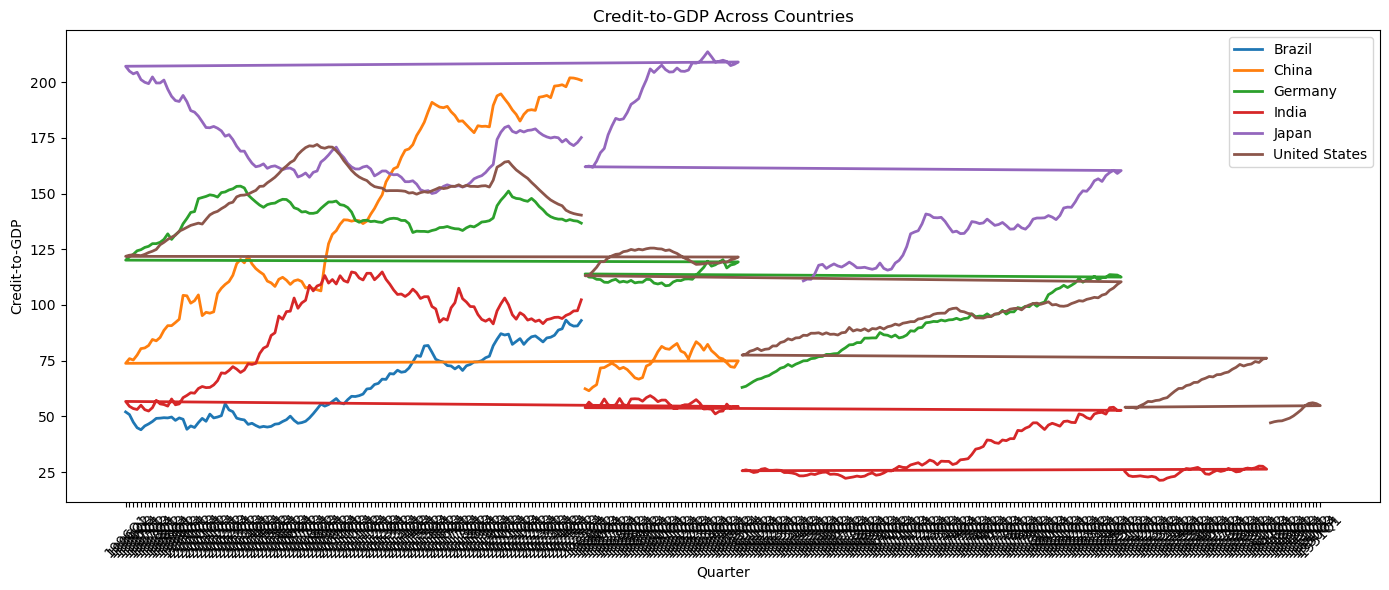

In [45]:
# ----------------------------------------------------
# Compare Countries
# ----------------------------------------------------

plt.figure(figsize=(14,6))

for country, data in df_analysis.groupby("BORROWERS_CTY_LABEL"):

    plt.plot(

        data["Quarter"].astype(str),

        data["OBS_VALUE"],

        linewidth=2,

        label=country

    )

plt.title("Credit-to-GDP Across Countries")

plt.xlabel("Quarter")

plt.ylabel("Credit-to-GDP")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

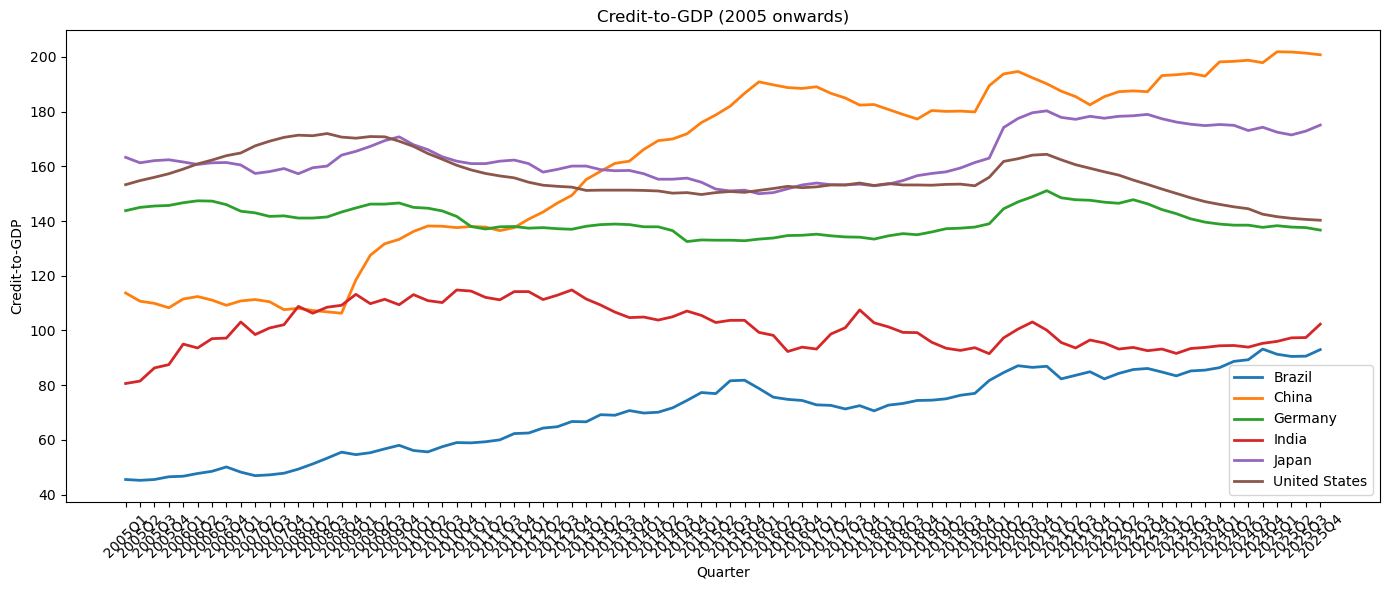

In [46]:
# ----------------------------------------------------
# Recent History
# ----------------------------------------------------

recent = df_analysis[
    df_analysis["Year"] >= 2005
]

plt.figure(figsize=(14,6))

for country, data in recent.groupby("BORROWERS_CTY_LABEL"):

    plt.plot(

        data["Quarter"].astype(str),

        data["OBS_VALUE"],

        linewidth=2,

        label=country

    )

plt.title("Credit-to-GDP (2005 onwards)")

plt.xlabel("Quarter")

plt.ylabel("Credit-to-GDP")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

<Figure size 800x500 with 0 Axes>

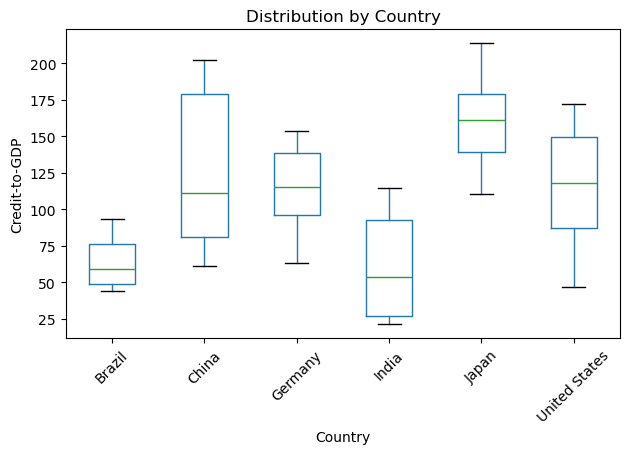

In [47]:
# ----------------------------------------------------
# Distribution of Credit-to-GDP
# ----------------------------------------------------

plt.figure(figsize=(8,5))

df_analysis.boxplot(

    column="OBS_VALUE",

    by="BORROWERS_CTY_LABEL",

    grid=False

)

plt.title("Distribution by Country")

plt.suptitle("")

plt.xlabel("Country")

plt.ylabel("Credit-to-GDP")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


In [48]:
# ----------------------------------------------------
# Country Dashboard
# ----------------------------------------------------

dashboard = (

    df_analysis

    .groupby("BORROWERS_CTY_LABEL")

    .agg(

        Latest=("OBS_VALUE","last"),

        Average=("OBS_VALUE","mean"),

        Minimum=("OBS_VALUE","min"),

        Maximum=("OBS_VALUE","max"),

        Std_Dev=("OBS_VALUE","std")

    )

    .round(2)

    .sort_values(
        "Latest",
        ascending=False
    )

)

dashboard

,Latest,Average,Minimum,Maximum,Std_Dev
BORROWERS_CTY_LABEL,,,,,
China,200.8,125.11,61.5,201.9,46.10
Japan,175.1,161.94,110.8,213.6,26.99
United States,140.3,113.35,47.1,172.0,34.69
Germany,136.7,116.63,63.0,153.3,24.97
India,102.3,57.86,21.3,114.8,30.38
Brazil,93.0,63.44,44.0,93.2,15.61


In [49]:
# ----------------------------------------------------
# Latest Country Ranking
# ----------------------------------------------------

display(
    ranking[
        [
            "Rank",
            "BORROWERS_CTY_LABEL",
            "Quarter",
            "OBS_VALUE"
        ]
    ]
)

,Rank,BORROWERS_CTY_LABEL,Quarter,OBS_VALUE
0,1,China,2025Q4,200.8
1,2,Japan,2025Q4,175.1
2,3,United States,2025Q4,140.3
3,4,Germany,2025Q4,136.7
4,5,India,2025Q4,102.3
5,6,Brazil,2025Q4,93.0


In [50]:
# ----------------------------------------------------
# Most Volatile Country
# ----------------------------------------------------

volatility = (

    df_analysis

    .groupby("BORROWERS_CTY_LABEL")["OBS_VALUE"]

    .std()

    .sort_values(ascending=False)

    .rename("Standard Deviation")

)

display(volatility)

BORROWERS_CTY_LABEL
China            46.100707
United States    34.689872
India            30.384912
Japan            26.986414
Germany          24.966681
Brazil           15.608948
Name: Standard Deviation, dtype: float64

In [51]:
# ----------------------------------------------------
# Historical Growth
# ----------------------------------------------------

growth = (

    df_analysis

    .groupby("BORROWERS_CTY_LABEL")

    .agg(

        First=("OBS_VALUE","first"),

        Latest=("OBS_VALUE","last")

    )

)

growth["Absolute Change"] = (
    growth["Latest"] - growth["First"]
)

growth = growth.sort_values(
    "Absolute Change",
    ascending=False
)

display(growth)

,First,Latest,Absolute Change
BORROWERS_CTY_LABEL,,,
China,62.4,200.8,138.4
United States,47.1,140.3,93.2
India,25.2,102.3,77.1
Germany,63.0,136.7,73.7
Japan,110.8,175.1,64.3
Brazil,52.0,93.0,41.0


In [52]:
# ----------------------------------------------------
# Cross-Country Correlation
# ----------------------------------------------------

corr_df = (

    df_analysis

    .pivot(

        index="Quarter",

        columns="BORROWERS_CTY_LABEL",

        values="OBS_VALUE"

    )

)

correlation = corr_df.corr()

display(correlation.round(2))

BORROWERS_CTY_LABEL,Brazil,China,Germany,India,Japan,United States
BORROWERS_CTY_LABEL,,,,,,
Brazil,1.00,0.95,-0.04,0.51,-0.28,0.21
China,0.95,1.00,0.59,0.78,-0.62,0.67
Germany,-0.04,0.59,1.00,0.88,0.55,0.95
India,0.51,0.78,0.88,1.00,0.35,0.94
Japan,-0.28,-0.62,0.55,0.35,1.00,0.47
United States,0.21,0.67,0.95,0.94,0.47,1.00


In [53]:
# ----------------------------------------------------
# Country Snapshot
# ----------------------------------------------------

snapshot = (

    df_analysis

    .groupby("BORROWERS_CTY_LABEL")

    .agg(

        First_Observation=("Quarter","min"),

        Latest_Observation=("Quarter","max"),

        Latest_Value=("OBS_VALUE","last"),

        Historical_Max=("OBS_VALUE","max"),

        Historical_Min=("OBS_VALUE","min")

    )

)

display(snapshot)

,First_Observation,Latest_Observation,Latest_Value,Historical_Max,Historical_Min
BORROWERS_CTY_LABEL,,,,,
Brazil,1996Q1,2025Q4,93.0,93.2,44.0
China,1985Q4,2025Q4,200.8,201.9,61.5
Germany,1960Q4,2025Q4,136.7,153.3,63.0
India,1951Q2,2025Q4,102.3,114.8,21.3
Japan,1964Q4,2025Q4,175.1,213.6,110.8
United States,1947Q4,2025Q4,140.3,172.0,47.1


# Conclusions

This notebook demonstrated how BIS SDMX data can be transformed from a collection of SDMX time series into an analysis-ready panel dataset for comparative macroeconomic analysis.

Using the BIS Total Credit dataset (`WS_TC`), we retrieved data for six major economies and performed a series of cross-country analyses.

## Key Findings

### 1. China recorded the highest Credit-to-GDP ratio

Among the selected economies, China reported the highest Credit-to-GDP ratio in the latest available quarter (2025Q4), followed by Japan and the United States.

| Rank | Country | Credit-to-GDP |
|------:|---------|--------------:|
| 1 | China | 200.8 |
| 2 | Japan | 175.1 |
| 3 | United States | 140.3 |
| 4 | Germany | 136.7 |
| 5 | India | 102.3 |
| 6 | Brazil | 93.0 |

---

### 2. China experienced the largest long-term increase

China showed the greatest historical increase in Credit-to-GDP, rising by approximately **138 percentage points** over the available sample period. The United States and India also recorded substantial long-run increases.

---

### 3. China exhibited the greatest historical volatility

Based on the standard deviation of the Credit-to-GDP series, China displayed the highest level of variability among the selected economies, while Brazil exhibited the lowest volatility.

---

### 4. Data availability differs across countries

The historical coverage varies considerably across economies.

- United States: 1947Q4 onwards
- India: 1951Q2 onwards
- Germany: 1960Q4 onwards
- Japan: 1964Q4 onwards
- China: 1985Q4 onwards
- Brazil: 1996Q1 onwards

This illustrates one of the practical considerations when conducting international macroeconomic analysis.

---

### 5. Several countries exhibit strong co-movement

The correlation analysis suggests strong positive relationships between several advanced economies. For example, Germany and the United States display a high historical correlation, while India also shows strong positive correlation with both Germany and the United States over the overlapping sample period.

---

## Summary

By the end of this notebook, we successfully:

- Retrieved multiple BIS SDMX time series using a single SDMX query.
- Built an analysis-ready panel dataset.
- Decoded SDMX metadata into human-readable labels.
- Compared macroeconomic indicators across countries.
- Ranked countries using the latest available observations.
- Evaluated historical growth and volatility.
- Explored relationships between countries through correlation analysis.

This notebook extends the SDMX workflow from single-country analysis (D5) to multi-country panel analysis and provides a foundation for more advanced statistical modelling and forecasting in subsequent notebooks.